# PETadex-alignment — component assignment pipeline

**One notebook, one folder.** This orchestrates the full paper-faithful pipeline end-to-end
and then analyses the result. It reproduces the v8 run exactly (46 components, 33,101 edges,
largest component 283) from the frozen curated 484-node PAZy set.

*The first step is always to sanity check and reproduce the logan results >> (**42 components / 3,178 edges**)

### Method (carried forward v4–v8, unchanged)
1. **Step 0: Engine sanity.** Rebuild the 213 v1 reference nodes, run the identical aligner +
   partition, and confirm the paper's **42 components / 3,178 edges**. Validates the engine, not
   the biology.
2. **Step 1: Nodes.** Collapse the curated PAZy TSV to md5-unique nodes (484); emit both FASTA
   orientations. v1 `component`/`cath` attached as a *descriptive overlay only*.
3. **Step 2: Alignment.** `usearch v11.0.667 -allpairs_local` (Docker `linux/amd64`), permissive
   `-acceptall`, both orientations. usearch is a Linux ELF binary run only through Docker here.
4. **Step 3: Partition.** Best HSP per pair by **max bits** (B4), post-filter **≥30% aaid +
   e<1e-5**, single-linkage connected components. For de-novo proteins >> the prior `component_id` is preserved
   for comparison only, never seeds the partition.

> Scientific constants live in `config.py`; the pipeline steps are `scripts/step*.py`; `run.sh`
> is the shell-equivalent of this notebook. Outputs land in `outputs/`.

In [1]:
import json, subprocess, sys
from pathlib import Path
import pandas as pd

# Locate the analysis/ root (holds config.py) from wherever the kernel started.
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config
OUT = config.OUTPUTS; OUT.mkdir(exist_ok=True)
DATE = config.DATE

def run_step(script, *args):
    "Run a pipeline script with the kernel's own Python; stream its output."
    cmd = [sys.executable, str(ROOT / "scripts" / script), *map(str, args)]
    print("$", "python", "scripts/" + script, *map(str, args))
    subprocess.run(cmd, check=True, cwd=ROOT)

# Provenance / environment sanity
import hashlib
got = hashlib.md5(config.INPUT_TSV.read_bytes()).hexdigest()
print("input md5   :", got, "OK" if got == config.INPUT_MD5 else "*** MISMATCH ***")
print("usearch bin :", (config.BIN / "usearch11").exists())
print("criterion   :", f"pct_id>={config.ID_MIN} AND evalue<{config.EVALUE_MAX:g}")

input md5   : 1d13e83691cc767c7ba9635c9bd2ed60 OK
usearch bin : True
criterion   : pct_id>=30.0 AND evalue<1e-05


## Step 0 — engine sanity  →  expect **42 components / 3,178 edges**

In [2]:
S0 = config.STEP0_DIR
run_step("step0_sanity.py")
config.usearch(S0 / "v1_213.fasta",     S0 / "v1_213_pairs.tsv")
config.usearch(S0 / "v1_213_rev.fasta", S0 / "v1_213_rev_pairs.tsv")
run_step("step23_graph.py", "--prefix", S0 / "v1_213", "--outdir", S0, "--tag", "step0", "--date", DATE)

s0 = json.loads((S0 / f"stats_step0_{DATE}.json").read_text())
assert (s0["n_components"], s0["edges_passing"]) == (42, 3178), s0
print(f"\n✅ Step-0 gate PASSED: {s0['n_components']} components / {s0['edges_passing']} edges "
      f"(matches the paper's 42)")

$ python scripts/step0_sanity.py
[step0] wrote 213 v1 nodes (205 unique md5) -> /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/step0_check/v1_213.fasta


usearch v11.0.667_i86linux64, 8.0Gb RAM, 10 cores
(C) Copyright 2013-18 Robert C. Edgar, all rights reserved.
https://drive5.com/usearch

From 2024 donated to public domain under CC0-1.0 license



usearch v11.0.667_i86linux64, 8.0Gb RAM, 10 cores
(C) Copyright 2013-18 Robert C. Edgar, all rights reserved.
https://drive5.com/usearch

From 2024 donated to public domain under CC0-1.0 license



$ python scripts/step23_graph.py --prefix /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/step0_check/v1_213 --outdir /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/step0_check --tag step0 --date 2026-07-21
[step23:step0] 213 nodes -> 42 components, 3178 edges (largest 90)

✅ Step-0 gate PASSED: 42 components / 3178 edges (matches the paper's 42)


## Step 1 — assemble md5-unique node set  →  expect **484 nodes**

In [3]:
run_step("step1_nodes.py")
s1 = json.loads((OUT / "combined_stats.json").read_text())
assert s1["n_nodes"] == 484, s1
pd.Series(s1).to_frame("value")

$ python scripts/step1_nodes.py
[step1] 484 nodes / 484 unique md5 (0 blank, 0 md5-collapsed) -> /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/combined.fasta


,value
input_tsv,/Users/Pixel/Documents/projects/plasticome/pet...
input_md5,1d13e83691cc767c7ba9635c9bd2ed60
v1_overlay_csv,/Users/Pixel/Documents/projects/plasticome/pet...
n_rows,484
n_blank_seq_dropped,0
n_rows_with_seq,484
n_nodes,484
n_md5_collapsed_rows,0
n_multi_row_nodes,0
n_unique_md5,484


## Step 2 — all-vs-all alignment (both orientations, Docker usearch)

In [4]:
config.usearch(OUT / "combined.fasta",     OUT / "combined_pairs.tsv")
config.usearch(OUT / "combined_rev.fasta", OUT / "combined_rev_pairs.tsv")
fwd = sum(1 for _ in (OUT / "combined_pairs.tsv").open())
rev = sum(1 for _ in (OUT / "combined_rev_pairs.tsv").open())
print(f"raw HSP rows: {fwd} fwd + {rev} rev = {fwd + rev}")

usearch v11.0.667_i86linux64, 8.0Gb RAM, 10 cores
(C) Copyright 2013-18 Robert C. Edgar, all rights reserved.
https://drive5.com/usearch

From 2024 donated to public domain under CC0-1.0 license



usearch v11.0.667_i86linux64, 8.0Gb RAM, 10 cores
(C) Copyright 2013-18 Robert C. Edgar, all rights reserved.
https://drive5.com/usearch

From 2024 donated to public domain under CC0-1.0 license



raw HSP rows: 45253 fwd + 45169 rev = 90422


## Step 3 — partition + deliverables  →  expect **46 components**

In [5]:
run_step("step23_graph.py", "--prefix", OUT / "combined", "--outdir", OUT, "--tag", "petadex", "--date", DATE)
run_step("annotate_source.py",
         "--assignment", OUT / f"component_assignment_petadex_{DATE}.csv",
         "--out",        OUT / f"cleaned_pazy_final_components_{DATE}.csv")
stats = json.loads((OUT / f"stats_petadex_{DATE}.json").read_text())
assert stats["n_components"] == 46 and stats["largest_component"] == 283, stats
pd.Series(stats).to_frame("value")

$ python scripts/step23_graph.py --prefix /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/combined --outdir /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs --tag petadex --date 2026-07-21
[step23:petadex] 484 nodes -> 46 components, 33101 edges (largest 283)
$ python scripts/annotate_source.py --assignment /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/component_assignment_petadex_2026-07-21.csv --out /Users/Pixel/Documents/projects/plasticome/petadex-alignment/analysis/outputs/cleaned_pazy_final_components_2026-07-21.csv


[annotate] wrote cleaned_pazy_final_components_2026-07-21.csv: 484 rows (484 assigned, 0 no_sequence), 46 components


,value
tag,petadex
date,2026-07-21
prefix,/Users/Pixel/Documents/projects/plasticome/pet...
partition_mode,flat de novo (no v1 anchor)
evalue_scale,1.0
db_letters_N,169346
usearch,"v11.0.667 -allpairs_local -acceptall, both ori..."
docker_platform,linux/amd64
edge_criterion,pct_id>=30.0 AND evalue<1e-05 @ 169346-residue db
n_nodes,484


---
# Results

Everything below reads only the `outputs/` CSVs produced above.

In [6]:
assign  = pd.read_csv(OUT / f"component_assignment_petadex_{DATE}.csv")
members = pd.read_csv(OUT / f"component_members_petadex_{DATE}.csv")
edges   = pd.read_csv(OUT / f"component_edges_petadex_{DATE}.csv")
print(f"{len(assign)} nodes | {len(members)} components | {len(edges)} passing edges")

484 nodes | 46 components | 33101 passing edges


### Headline counts

In [7]:
headline = {
    "Source rows / nodes (md5-unique)": len(assign),
    "Search space N (residues)":        stats["db_letters_N"],
    "Aligned pairs (best HSP)":         stats["aligned_pairs"],
    "Edges passing ≥30% & e<1e-5":      stats["edges_passing"],
    "Components":                       stats["n_components"],
    "Singletons":                       stats["n_singletons"],
    "Non-singleton components":         stats["n_components"] - stats["n_singletons"],
    "Largest component":                stats["largest_component"],
}
pd.Series(headline, name="value").to_frame()

,value
Source rows / nodes (md5-unique),484
Search space N (residues),169346
Aligned pairs (best HSP),44659
Edges passing ≥30% & e<1e-5,33101
Components,46
Singletons,23
Non-singleton components,23
Largest component,283


### Largest components (v1 overlay is descriptive only)

In [8]:
top = members.sort_values("size_rank").head(10).copy()
top["v1_overlay_n"] = top["n_with_v1_overlay"]
top[["size_rank", "component_id", "n_members", "v1_overlay_n",
     "canonical_label", "v1_component_spread", "cath_folds"]].set_index("size_rank")

,component_id,n_members,v1_overlay_n,canonical_label,v1_component_spread,cath_folds
size_rank,,,,,,
1,C001,283,74,1,1;20;35,3.40.50.1820
2,C010,48,6,47,9,3.60.70.12
3,C008,25,17,44,10,3.90.1300.10
4,C006,18,16,36,2,3.40.50.1820
5,C004,15,11,30,23,3.40.50.1820
6,C032,10,5,105,16,NaN
7,C011,8,5,52,21,3.40.50.1820
8,C021,7,6,70,25,3.40.50.1820
9,C007,5,5,39,4,3.40.50.1820


### v1-overlay coherence — *report, don't enforce*

In [9]:
n_overlay = int((assign["v1_component"].notna() & (assign["v1_component"] != "")).sum())
split = stats["n_v1_labels_split_across_components"]
print(f"{n_overlay}/{len(assign)} nodes carry a v1 overlay")
print(f"v1 labels split across >1 component: {split}   "
      f"({'✅ every v1 family maps to exactly one component' if split == 0 else '⚠️ see stats'})")

191/484 nodes carry a v1 overlay
v1 labels split across >1 component: 0   (✅ every v1 family maps to exactly one component)


### Fragment / substring caveats (G3) — no fragments were filtered

In [10]:
short = assign[assign["sequence_length"] < 100].sort_values("sequence_length")
print(f"{len(short)} node(s) < 100 aa:")
short[["identifier", "enzyme_name", "sequence_length", "component_id", "size_rank"]]

1 node(s) < 100 aa:


,identifier,enzyme_name,sequence_length,component_id,size_rank
333,50,Arylacylamidase,28,C008,3


### Component-size distribution

Matplotlib is building the font cache; this may take a moment.


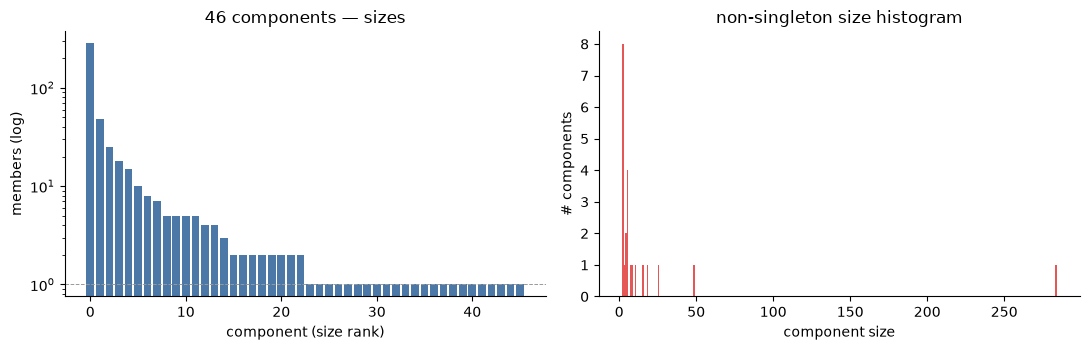

In [11]:
import matplotlib.pyplot as plt
sizes = members["n_members"].sort_values(ascending=False).values
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.bar(range(len(sizes)), sizes, color="#4C78A8")
a1.set(yscale="log", xlabel="component (size rank)", ylabel="members (log)",
       title=f"{len(sizes)} components — sizes")
a1.axhline(1, color="#999", lw=.7, ls="--")

nonsing = sizes[sizes > 1]
a2.hist(nonsing, bins=range(1, int(nonsing.max()) + 3), color="#E45756")
a2.set(xlabel="component size", ylabel="# components",
       title="non-singleton size histogram")
for ax in (a1, a2):
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

### Largest component (C001, α/β-hydrolase) — neighbourhood graph

C001: 283 nodes, 31636 internal edges, median degree 250


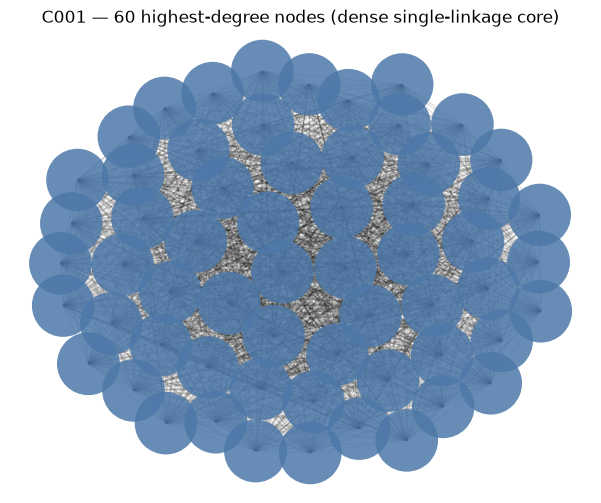

In [12]:
import networkx as nx
c001 = assign.loc[assign["component_id"] == members.iloc[0]["component_id"], "node_id"]
c001 = set(c001)
sub = edges[edges["node_a"].isin(c001) & edges["node_b"].isin(c001)]
G = nx.from_pandas_edgelist(sub, "node_a", "node_b")
print(f"C001: {len(c001)} nodes, {G.number_of_edges()} internal edges, "
      f"median degree {int(pd.Series(dict(G.degree())).median())}")

# Draw the induced subgraph on the 60 highest-degree nodes to keep it legible.
deg = dict(G.degree())
keep = [n for n, _ in sorted(deg.items(), key=lambda kv: -kv[1])[:60]]
H = G.subgraph(keep)
fig, ax = plt.subplots(figsize=(7.5, 6))
pos = nx.spring_layout(H, seed=1, k=0.35)
nx.draw_networkx_edges(H, pos, alpha=0.12, ax=ax)
nx.draw_networkx_nodes(H, pos, node_size=[8 * deg[n] for n in H], node_color="#4C78A8",
                       linewidths=0, alpha=0.85, ax=ax)
ax.set(title="C001 — 60 highest-degree nodes (dense single-linkage core)"); ax.axis("off")
plt.show()

---
### Validation gates

| gate | expected | result |
|---|---|---|
| Step-0 engine sanity | 42 comps / 3,178 edges | asserted above |
| md5-unique nodes into graph | 484 | asserted above |
| Every node in exactly one component | 484/484 | annotate step |
| Components | 46 | asserted above |
| v1 labels split across components | 0 | reported above |

**Provenance** — input `cleaned_pazy_final.tsv` md5 `1d13e83691cc767c7ba9635c9bd2ed60`;
aligner usearch v11.0.667 `-allpairs_local` (Docker linux/amd64). This notebook is the
authoritative driver; `run.sh` is its shell twin. See `REPORT.md` for the full narrative.